In [1]:
from py_files.setup import *
setup_notebook()

# `Aggregate labour share` - *properly calculated*

*`1. get the GVA for every year`*

In [2]:
# 0. extraction helper
def code_token(x: pd.Index) -> pd.Series:
    s = pd.Series(x, dtype="string")
    return s.str.extract(r"^\s*([^ ]+)", expand=False)

# 1. extract codes
m_code = code_token(var_groups.mothers)          
s_code = code_token(var_groups.subs)     

# 2. mother letter of sub
s_mother = s_code.str[0]
groups = s_code.groupby(s_mother).apply(list).to_dict()

In [3]:
NABP36 = DstApi('NABP36')
df = NABP36.variable_levels('TRANSAKT',language='en')
# df.loc[df["id"].eq("B2A3GD"), "text"].iloc[0]

In [4]:
NABP36 = DstApi('NABP36')

# 1. set up relevant inputs
transact = [
    'B1GD',  # B.1g Gross value added
    'D1D',   # D.1 Compensation of employees
    'B2A3GD',
]

# 2. set up fetch
params_e = {
    'table': 'NABP36',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'PRISENHED', 'values': ['V']},     # current prices (m. DKK)
        {'code': 'Tid', 'values': ['*']},
        {'code': 'BRANCHE', 'values': ['*']},
        {'code': 'TRANSAKT', 'values': transact}
        ]
}

# 3. get and clean
df_e_ = NABP36.get_data(params=params_e)
df_e_['INDHOLD'] = pd.to_numeric(df_e_['INDHOLD'], errors='coerce')

df_e = df_e_.pivot_table(
    index=['TID','BRANCHE'],
    columns='TRANSAKT',
    values='INDHOLD'
).reset_index()

df_e = df_e.rename(columns={
    'B.1g Gross value added'   : 'GVA',
    'D.1 Compensation of employees': 'e_comp',
    'B.2g+B.3g Gross operating surplus and mixed income':'e_mixed_inc'
})

df_e['e_total'] = df_e['e_comp']

# 4. compute labor share by industry
df_e['labor_share'] = df_e['e_total'] / df_e['GVA'] * 100

df_e_slim = df_e[['TID','BRANCHE','labor_share','GVA']].copy()

# 5. drop total
df_e_slim = df_e_slim[~df_e_slim['BRANCHE'].eq('Total')].copy()

# 6. extract industry code
df_e_slim['branche_code'] = code_token(df_e_slim['BRANCHE'])

*`2. Defined fixed list industries into sectors`*

Do a fixed classification of industries and check that they are sane.

In [5]:
# 1. map to type
df_e_slim['type'] = np.select(
    [df_e_slim['branche_code'].isin(var_groups.consumption_industries),
     df_e_slim['branche_code'].isin(var_groups.investment_industries)],
    ['C', 'I'],
    default='x'
)

# 2. alternative, no pharma
df_e_slim_np = df_e_slim[~df_e_slim['branche_code'].eq('CF')].copy() # ~

*`3. plot`*

In [6]:
# 1. compute weighted averages
weighted_avg = df_e_slim.groupby(['TID','type'], group_keys=False).apply(
    lambda x: (x['labor_share'] * x['GVA']).sum() / x['GVA'].sum(),
    include_groups=False
).reset_index(name='weighted_labor_share')

weighted_avg_np = df_e_slim_np.groupby(['TID','type'], group_keys=False).apply(
    lambda x: (x['labor_share'] * x['GVA']).sum() / x['GVA'].sum(),
    include_groups=False
).reset_index(name='weighted_labor_share')

# 2. keep only type I and C
weighted_avg = weighted_avg[weighted_avg['type'].isin(['C', 'I'])].copy()
weighted_avg_np = weighted_avg_np[weighted_avg_np['type'].isin(['C', 'I'])].copy()

*plot*

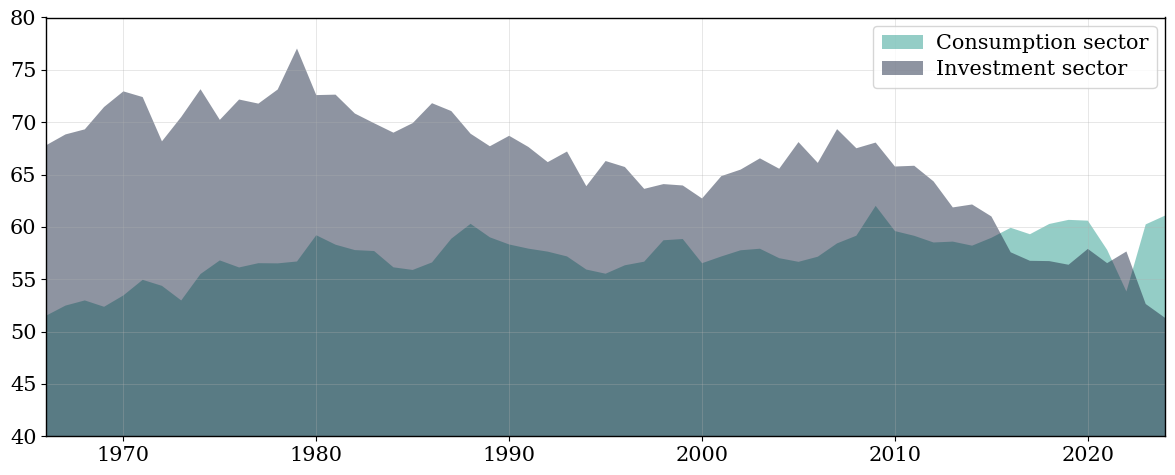

<Figure size 640x480 with 0 Axes>

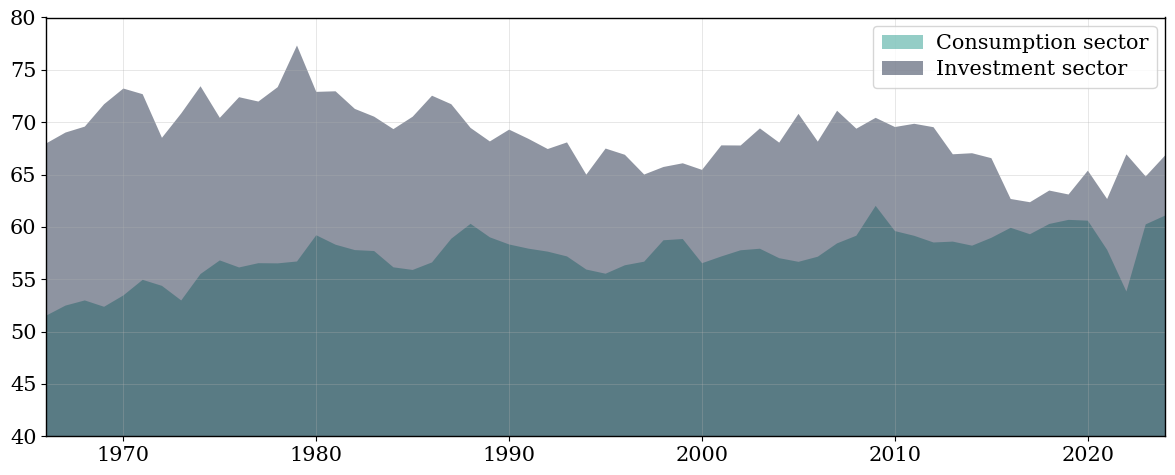

<Figure size 640x480 with 0 Axes>

In [8]:
# 1. full category
# Pivot data for easier plotting
plot_data = weighted_avg.pivot(index='TID', columns='type', values='weighted_labor_share')
plot_data_2 = weighted_avg_np.pivot(index='TID', columns='type', values='weighted_labor_share')

fig, ax = plt.subplots(1, 1, figsize=(12, 5))

x = plot_data.index
types = plot_data.columns.tolist()

colors = ["#2A9D8F", "#1F2A44"]  # tangible = deep navy, intangible = teal
lable = ["Consumption sector", "Investment sector"]

# Plot each type with transparency
for i, type_name in enumerate(types):
    labor_share = plot_data[type_name]
    ax.fill_between(x, 0, labor_share, alpha=0.5, linewidth=0, label=lable[i], color=colors[i])

# Subtle baseline
ax.axhline(0, color="0.2", linewidth=1.2)

ax.set_xlim(x.min(), x.max())
ax.set_ylim(40, 80)

# Minimalist grid
ax.grid(linewidth=0.6, alpha=0.35)
ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=6))

ax.legend()

plt.tight_layout()
plt.savefig('0_output/LS_1.png')
plt.show()

# 2. no pharma
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

y = plot_data_2.index
types = plot_data_2.columns.tolist()
colors = ["#2A9D8F", "#1F2A44"] 
lable = ["Consumption sector", "Investment sector"]

for i, type_name in enumerate(types):
    labor_share = plot_data_2[type_name]
    ax.fill_between(y, 0, labor_share, alpha=0.5, linewidth=0, label=lable[i], color=colors[i])

ax.axhline(0, color="0.2", linewidth=1.2)
ax.set_xlim(y.min(), y.max())
ax.set_ylim(40, 80)
ax.grid(linewidth=0.6, alpha=0.35)
ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=6))

ax.legend()

plt.tight_layout()
plt.savefig('0_output/LS_2.png')
plt.show()

*`4. Sanity`*

Check if calculated labour use shares match definitions.

In [ ]:
# 1. LS data
df_24 = df_e_slim[df_e_slim['TID'].eq(2024)][
    ['branche_code','labor_share','BRANCHE','GVA','type']].copy()

# 2. share data
year_result = il.compute_leontief_for_year(2024)
parent_shares = il.aggregate_use_shares_to_parent(year_result)

# 3. merge
df_merged = df_24.merge(
    parent_shares,
    left_on='branche_code',
    right_on='parent',
    how='left'
)

# 4. clean
df_m = df_merged[
    ['parent','type','labor_share','GVA','C_share','I_share','C_direct','I_direct']
    ].copy()

Processing year 2024...


In [ ]:
df_m.sort_values('C_share', ascending=False, inplace=True)
df_m

,parent,type,labor_share,GVA,C_share,I_share,C_direct,I_direct
38,SB,C,100.000000,4882.0,100.000000,0.000000,100.000000,0.000000
26,LB,C,4.037388,195894.0,99.971981,0.028019,99.971981,0.028019
35,QB,C,97.639848,124653.0,99.831506,0.168494,99.854608,0.145392
34,QA,C,93.883925,123903.0,98.253297,1.746703,98.590244,1.409756
31,O,C,79.677963,121725.0,97.752650,2.247350,98.706605,1.293395
20,I,C,78.832879,42155.0,95.581280,4.418720,99.748316,0.251684
2,CA,C,62.294280,40893.0,94.480285,5.519715,95.824135,4.175865
0,A,C,53.080691,27153.0,93.790219,6.209781,97.860313,2.139687
37,SA,C,70.857947,36226.0,92.202436,7.797564,96.606772,3.393228
24,K,C,44.308840,142572.0,91.375754,8.624246,93.153891,6.846109
